# LUMOS evaluation

The model predicts parameters of an analytical forward model rather than a
spectrum directly, and is trained with the input window length sampled per step.
This notebook tests what that buys: one model that serves any number of input
frames, down to a single one.

Three things are shown, in order.

1. Metrics on the full window, with the baselines needed to read them.
2. Accuracy against the number of input frames, which is the central claim.
3. The decomposition itself, for one spectrum.

Everything is scored against `gt_raman` over a common wavenumber window, on the
test split, and classical correction is always given the same frames the model
receives so neither gets a longer exposure than the other.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import xarray as xr
from pybaselines import polynomial, whittaker
from scipy.optimize import linear_sum_assignment
from scipy.signal import savgol_filter
import lumos
from lumos.metrics import pearson_r, psnr, scale_invariant_psnr, spectral_angle_mapper
from lumos.vae_module import VAEModule


In [2]:
# Runs live in two trees: the package one from earlier work, and the repository
# one used since. Resolving across both avoids silently missing a run.
CHECKPOINT_DIRS = [
    Path(lumos.__file__).resolve().parents[2] / "checkpoints",
    Path(lumos.__file__).resolve().parent / "checkpoints",
]
SPLIT = "test"
EVAL_WINDOW = (400.0, 1800.0)      # common wavenumber range, None for the full axis
T_GRID = [16, 8, 4, 2, 1]          # window lengths to evaluate at

DATA = Path("~/Developments/Raman/oracle/data/processed").expanduser()
GLASGOW = DATA / "glasgow/glasgow_16_trimmed_smoothed.zarr"
CANCER = DATA / "cancer/cancer_nh2_16_noisy.zarr"
FISH = DATA / "fish/fish_6frame.zarr"

# Labels key every result, so they must be unique. Pre-Voigt checkpoints are
# rejected on load by the retirement guard, so everything here is from the
# current code. The matrix needs one run per training window; the 7.28M rows
# are still training, so the 0.47M rows carry the fixed-versus-uniform contrast.
# Grouped by what each set demonstrates. All are current-code runs; the
# pre-Voigt ones are rejected on load by the retirement guard.
RUNS = [
    # -- the window matrix. 7.28M, inductive, blur pinned to provenance (4 cm-1),
    #    L1 0.003, learning-rate multipliers at 1. Rows of the matrix.
    dict(label="cancer T=64", zarr=CANCER, run="mf_u64_20260901_175517"),
    dict(label="cancer T=16", zarr=CANCER, run="mf_u16_20260901_175401"),
    dict(label="cancer T=4", zarr=CANCER, run="mf_u04_20260901_175426"),
    dict(label="cancer T=1", zarr=CANCER, run="mf_t01_20260901_175450"),

    # -- fixed-window controls. Should work only on their own diagonal.
    dict(label="cancer fixed T=16", zarr=CANCER, run="fw_t16_20260901_173411"),
    dict(label="cancer fixed T=4", zarr=CANCER, run="fw_t4_20260901_173351"),

    # -- the smoothing regression. Same size and protocol, blur left fitted:
    #    it rails at its 15 cm-1 cap and erases the Raman band.
    dict(label="cancer T=16 [BEFORE: blur fitted]", zarr=CANCER,
         run="mx_u16_20260901_160952"),

    # -- the cause, at 0.47M. shape_lr_multiplier was 1 in May and 10 from
    #    August; a tenfold rate on the blur width is most of the regression.
    #    Both have a FITTED blur, so this is the fix without any pinning.
    dict(label="cancer 0.47M multipliers 1", zarr=CANCER,
         run="lrm_all1_20260901_152130"),
    dict(label="cancer 0.47M multipliers 10", zarr=CANCER,
         run="in_induct_base_20260901_112649"),

    # -- reproduction of the paper number under its own protocol: 7.28M,
    #    transductive, fitted blur. The fixed arm is the like-for-like.
    dict(label="cancer paper repro, fixed", zarr=CANCER,
         run="rp_trans_fixed_20260901_172207"),
    dict(label="cancer paper repro, uniform", zarr=CANCER,
         run="rp_trans_l1003_20260901_172146"),

    # -- glasgow, real data. Blur provenance ~14 cm-1 from the 100 um slit, so
    #    the default cap is already about right and pinning changes little.
    dict(label="glasgow T=16", zarr=GLASGOW, run="gl_pin14_20260901_155502"),

    # -- still training at the time of writing, so their rows are not readable.
    #    Multipliers at 1 with a fitted blur at 7.28M: if the blur settles low,
    #    the sharpness needs no provenance value and no pinning.
    # dict(label="cancer mult 1, blur fitted [TRAINING]", zarr=CANCER,
    #      run="sh_mult1_fitted_20260901_214932"),
    # dict(label="cancer mult 1, plateau [TRAINING]", zarr=CANCER,
    #      run="sh_mult1_plateau_20260901_214953"),
]

SAVGOL_WINDOW, SAVGOL_ORDER, AIRPLS_LAM, IMODPOLY_ORDER = 11, 3, 1e6, 5
print("checkpoints:", *[str(d) for d in CHECKPOINT_DIRS], sep="\n  ")

checkpoints:
  /home/tom/Developments/lumos/checkpoints
  /home/tom/Developments/lumos/src/lumos/checkpoints


## Helpers

In [3]:
def load_model(run):
    """Load a run's final weights. last.ckpt is the end of training."""
    hits = [d / run / "last.ckpt" for d in CHECKPOINT_DIRS
            if (d / run / "last.ckpt").exists()]
    if not hits:
        raise FileNotFoundError(
            f"{run} is in neither of {[str(d) for d in CHECKPOINT_DIRS]}")
    path = hits[0]
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    model = VAEModule.load_from_checkpoint(
        path, map_location="cuda" if torch.cuda.is_available() else "cpu",
        strict=False,
        decoder_dim=ckpt["state_dict"]["model.decoder.trunk_shared.0.weight"].shape[0],
    )
    return model.eval(), ckpt["hyper_parameters"]


def load_data(zarr_path, split=SPLIT):
    ds = xr.open_zarr(str(zarr_path))
    idx = np.where(ds["split"].values == split)[0]
    fd = float(ds.attrs.get("frame_duration_s", 0.1))
    gt_var = "gt_raman_smoothed" if "gt_raman_smoothed" in ds else "gt_raman"
    opt = lambda n: ds[n].values[idx] if n in ds else None
    return dict(
        name=Path(str(zarr_path)).name, idx=idx, frame_duration=fd,
        wn=ds.coords["wavenumber"].values,
        ts=ds["time_series"].transpose("sample", "time", "wavenumber").values[idx],
        ts_all=ds["time_series"].transpose("sample", "time", "wavenumber").values,
        gt=ds[gt_var].values[idx] / fd,
        labels=np.array([str(v) for v in ds["labels"].values[idx]]),
        labels_all=np.array([str(v) for v in ds["labels"].values]),
        # Noise-free Raman-dominated frame, synthetic stores only. gt_raman
        # itself carries shot noise, so judging sharpness against it penalises
        # a model for not reproducing noise.
        clean=(ds["intensity_clean"].transpose("sample", "time", "wavenumber")
               .values[idx][:, -1, :] / fd) if "intensity_clean" in ds else None,
        bases_gt=opt("fluorophore_bases_gt"), rates_gt=opt("decay_rates_gt"),
        abund_gt=opt("abundances_gt"), dye_names=opt("fluorophore_name"),
    )


def recover(model, series, n_frames, batch=32):
    """Recovered Raman from the first n_frames of each spectrum."""
    std = model.model.dataset_std
    device = next(model.parameters()).device
    out = []
    with torch.no_grad():
        for i in range(0, len(series), batch):
            x = series[i:i + batch, :n_frames, :].astype(np.float32)
            x = torch.from_numpy(x).to(device).transpose(1, 2) / std
            out.append(model.model(x, sample=False)[5].cpu().numpy())
    return np.concatenate(out)


def debaseline(spectra, method="airpls", smooth=True):
    """Classical background removal, the alternative this model competes with."""
    out = np.empty_like(spectra, dtype=np.float64)
    for i, s in enumerate(spectra):
        s = s.astype(np.float64)
        if smooth:
            s = savgol_filter(s, SAVGOL_WINDOW, SAVGOL_ORDER)
        base = (whittaker.iarpls(s, lam=AIRPLS_LAM)[0] if method == "airpls"
                else polynomial.imodpoly(s, poly_order=IMODPOLY_ORDER)[0])
        out[i] = s - base
    return out


def eval_mask(wn):
    if EVAL_WINDOW is None:
        return np.ones(len(wn), dtype=bool)
    return (wn >= EVAL_WINDOW[0]) & (wn <= EVAL_WINDOW[1])

In [4]:
def score(gt, pred):
    """Mean over spectra of each metric."""
    row = {
        "PSNR": np.mean([psnr(gt[i], pred[i]) for i in range(len(gt))]),
        "SI-PSNR": np.mean([scale_invariant_psnr(gt[i], pred[i]) for i in range(len(gt))]),
        "Pearson": np.mean([pearson_r(gt[i], pred[i]) for i in range(len(gt))]),
        "SAM": np.mean([spectral_angle_mapper(gt[i], pred[i]) for i in range(len(gt))]),
    }
    return row

## Load models and predict

Each model is paired with the store it was trained on, since its wavenumber grid
is fixed at training time.

In [5]:
datasets, model_info = {}, {}

labels = [c["label"] for c in RUNS]
assert len(set(labels)) == len(labels), "RUNS labels must be unique"

for cfg in RUNS:
    name = Path(str(cfg["zarr"])).name
    if name not in datasets:
        datasets[name] = load_data(cfg["zarr"])
        print(f"{name}: {len(datasets[name]['idx'])} test spectra")
    d = datasets[name]
    model, hp = load_model(cfg["run"])
    assert hp["n_wavenumbers"] == len(d["wn"]), f"{cfg['label']}: wavenumber mismatch"
    model_info[cfg["label"]] = dict(model=model, hparams=hp, data=d)
    print(f"  {cfg['label']:20s} T={hp['n_times_train']:<3} "
          f"conv={hp.get('conv_channels')} sampling={hp.get('t_sampling')!r}")

cancer_nh2_16_noisy.zarr: 127 test spectra
[VAE init] n_raman_peaks=300
[VAE init] head_abundance: weight_norm=5.563  bias=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]  (softplus -> [0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996])
  cancer T=64          T=64  conv=64,128,256,512 sampling='uniform'
[VAE init] n_raman_peaks=300
[VAE init] head_abundance: weight_norm=5.572  bias=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]  (softplus -> [0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.69314718246459

## Metrics at the full window

`constant` emits the mean training spectrum for every cell. It uses the ground
truth, so it is not a competing method, only a check on whether a metric can
tell a useful model from a useless one. Where it wins, that metric cannot.

In [6]:
rows = []
for label, info in model_info.items():
    m, d = info["model"], info["data"]
    mask = eval_mask(d["wn"])
    n_max = m.hparams.n_times_train
    pred = recover(m, d["ts"], n_max)
    rows.append(dict(method=label, **score(d["gt"][:, mask], pred[:, mask])))

for name, d in datasets.items():
    mask = eval_mask(d["wn"])
    summed = d["ts"][:, :16, :].sum(1) / (16 * d["frame_duration"])
    for method in ("airpls", "imodpoly"):
        rows.append(dict(method=f"{d['name'].split('_')[0]} classical {method}",
                         **score(d["gt"][:, mask], debaseline(summed, method)[:, mask])))

pd.DataFrame(rows).set_index("method").round(3)

,PSNR,SI-PSNR,Pearson,SAM,gain
method,,,,,
cancer T=64,20.768,21.962,0.913,14.535,1.002
cancer T=16,19.174,20.024,0.863,18.004,0.958
cancer T=4,16.620,17.799,0.753,23.318,0.996
cancer T=1,13.571,15.957,0.607,29.173,1.067
cancer fixed T=16,17.799,19.194,0.836,20.622,0.756
cancer fixed T=4,16.525,17.825,0.760,24.538,0.706
cancer T=16 [BEFORE: blur fitted],17.992,19.701,0.853,19.257,0.720
cancer 0.47M multipliers 1,17.996,19.139,0.831,20.454,0.780
cancer 0.47M multipliers 10,17.346,18.791,0.815,21.774,0.721


## Accuracy against the number of input frames

The central claim. A model trained with the window sampled per step should hold
its accuracy as frames are removed; a fixed-window model should not, since the
encoder pools over time and has only ever seen one window length.

Classical correction is applied to the sum of the same frames, so no method gets
a longer exposure than another.

PSNR  SI-PSNR  Pearson     SAM    gain
method                     T                                           
cancer 0.47M multipliers 1 1   17.054   18.456    0.799  22.476   0.714
                           2   17.343   18.471    0.801  22.346   0.753
                           4   17.506   18.583    0.806  21.963   0.767
                           8   17.676   18.802    0.816  21.375   0.764
                           16  17.996   19.139    0.831  20.454   0.780
...                               ...      ...      ...     ...     ...
glasgow uncorrected        1  -21.671   15.513    0.578  43.871  31.400
                           2  -21.118   15.718    0.598  43.758  31.094
                           4  -20.298   15.950    0.616  43.591  29.877
                           8  -19.145   16.272    0.637  43.313  27.220
                           16 -17.617   16.742    0.661  42.882  24.580

[82 rows x 5 columns]

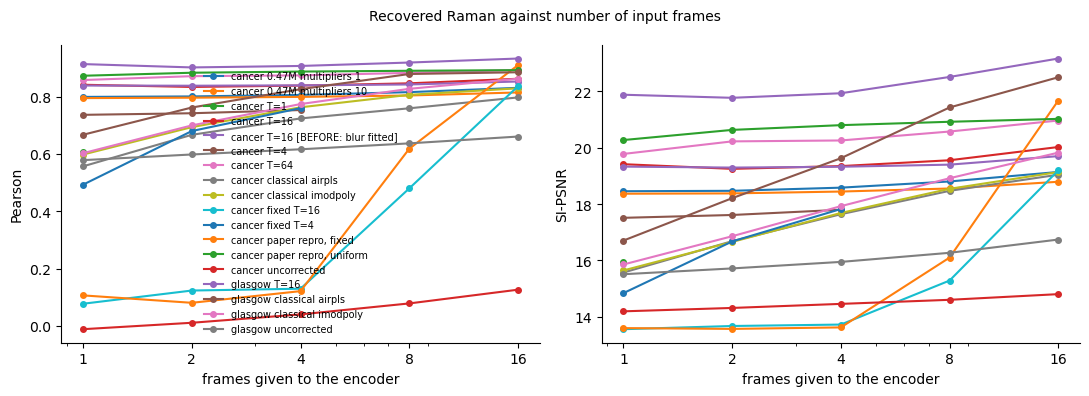

In [7]:
rows = []
for label, info in model_info.items():
    m, d = info["model"], info["data"]
    mask = eval_mask(d["wn"])
    for T in [t for t in T_GRID if t <= m.hparams.n_times_train]:
        pred = recover(m, d["ts"], T)[:, mask]
        rows.append(dict(method=label, T=T, **score(d["gt"][:, mask], pred)))

for name, d in datasets.items():
    mask = eval_mask(d["wn"])
    for T in T_GRID:
        summed = d["ts"][:, :T, :].sum(1) / (T * d["frame_duration"])
        stem = d["name"].split("_")[0]
        for meth in ("airpls", "imodpoly"):
            rows.append(dict(method=f"{stem} classical {meth}", T=T,
                             **score(d["gt"][:, mask],
                                     debaseline(summed, method=meth)[:, mask])))
        # No baseline removal at all, as the floor every method must clear.
        rows.append(dict(method=f"{stem} uncorrected", T=T,
                         **score(d["gt"][:, mask], summed[:, mask])))

window = pd.DataFrame(rows).set_index(["method", "T"]).sort_index()
display(window.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for method, grp in window.reset_index().groupby("method"):
    grp = grp.sort_values("T")
    style = "--" if method.startswith("classical") else "-"
    for ax, metric in zip(axes, ("Pearson", "SI-PSNR")):
        ax.plot(grp["T"], grp[metric], style, marker="o", ms=4, label=method)
for ax, metric in zip(axes, ("Pearson", "SI-PSNR")):
    ax.set(xlabel="frames given to the encoder", ylabel=metric, xscale="log")
    ax.set_xticks(T_GRID)
    ax.set_xticklabels(T_GRID)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(fontsize=7, frameon=False)
fig.suptitle("Recovered Raman against number of input frames", fontsize=10)
plt.tight_layout()
plt.show()

## The window matrix

Rows are the window a model was trained on, columns the window it is evaluated
at. A model trained with the window sampled per step should hold its accuracy
across the whole row; a fixed-window model should only work on its diagonal.

Classical methods have no training window, so they occupy a single row and are
given the sum of the same frames, which is the like-for-like comparison on
information. It is not quite like-for-like on noise: summing T readouts incurs
the read term T times where one long exposure incurs it once, which slightly
favours the model. `NaN` means the model was never trained that wide.


In [8]:
def window_matrix(metric="Pearson"):
    """Training window against evaluation window, one metric."""
    m = window.reset_index().pivot(index="method", columns="T", values=metric)
    order = ([k for k in model_info if "classical" not in k and "uncorrected" not in k]
             + [k for k in m.index if "classical" in k or "uncorrected" in k])
    return m.reindex([k for k in order if k in m.index])


def train_window(label):
    """The window a run was trained on, for labelling the rows."""
    info = model_info.get(label)
    return int(info["model"].hparams.n_times_train) if info else None


for metric in ("Pearson",):
    print(f"\n=== {metric}: rows trained at, columns evaluated at")
    display(window_matrix(metric).round(3))

# Handy for a heatmap: models only, indexed by their training window.
model_rows = [k for k in model_info]
mx = window_matrix("Pearson").loc[model_rows]
mx.index = [f"{k}  (trained T={train_window(k)})" for k in mx.index]
mx



=== Pearson: rows trained at, columns evaluated at


T,1,2,4,8,16
method,,,,,
cancer T=64,0.858,0.872,0.874,0.883,0.893
cancer T=16,0.842,0.834,0.839,0.847,0.863
cancer T=4,0.737,0.742,0.753,NaN,NaN
cancer T=1,0.607,NaN,NaN,NaN,NaN
cancer fixed T=16,0.077,0.123,0.130,0.480,0.836
cancer fixed T=4,0.493,0.680,0.760,NaN,NaN
cancer T=16 [BEFORE: blur fitted],0.839,0.838,0.840,0.843,0.853
cancer 0.47M multipliers 1,0.799,0.801,0.806,0.816,0.831
cancer 0.47M multipliers 10,0.795,0.796,0.799,0.804,0.815



=== gain: rows trained at, columns evaluated at


T,1,2,4,8,16
method,,,,,
cancer T=64,0.956,0.998,0.998,1.006,1.006
cancer T=16,0.968,0.970,0.962,0.958,0.958
cancer T=4,1.009,1.007,0.996,NaN,NaN
cancer T=1,1.067,NaN,NaN,NaN,NaN
cancer fixed T=16,43.360,11.641,5.953,0.852,0.756
cancer fixed T=4,0.780,0.664,0.706,NaN,NaN
cancer T=16 [BEFORE: blur fitted],0.692,0.712,0.708,0.708,0.720
cancer 0.47M multipliers 1,0.714,0.753,0.767,0.764,0.780
cancer 0.47M multipliers 10,0.658,0.714,0.719,0.719,0.721


T,1,2,4,8,16
cancer T=64 (trained T=64),0.858108,0.871686,0.874421,0.883149,0.893222
cancer T=16 (trained T=16),0.841654,0.834029,0.838725,0.846653,0.862599
cancer T=4 (trained T=4),0.736607,0.742186,0.753350,NaN,NaN
cancer T=1 (trained T=1),0.606659,NaN,NaN,NaN,NaN
cancer fixed T=16 (trained T=16),0.077057,0.123141,0.129559,0.479722,0.836244
cancer fixed T=4 (trained T=4),0.492964,0.680072,0.760042,NaN,NaN
cancer T=16 [BEFORE: blur fitted] (trained T=16),0.838890,0.838303,0.839562,0.842657,0.852995
cancer 0.47M multipliers 1 (trained T=16),0.799249,0.800910,0.806138,0.815892,0.830973
cancer 0.47M multipliers 10 (trained T=16),0.795064,0.796495,0.799287,0.804175,0.814831
"cancer paper repro, fixed (trained T=16)",0.106171,0.080296,0.121068,0.618189,0.910061


### The same thing, qualitatively

One model's recovered spectrum at every window length, over the ground truth,
with classical correction of a single frame for contrast.

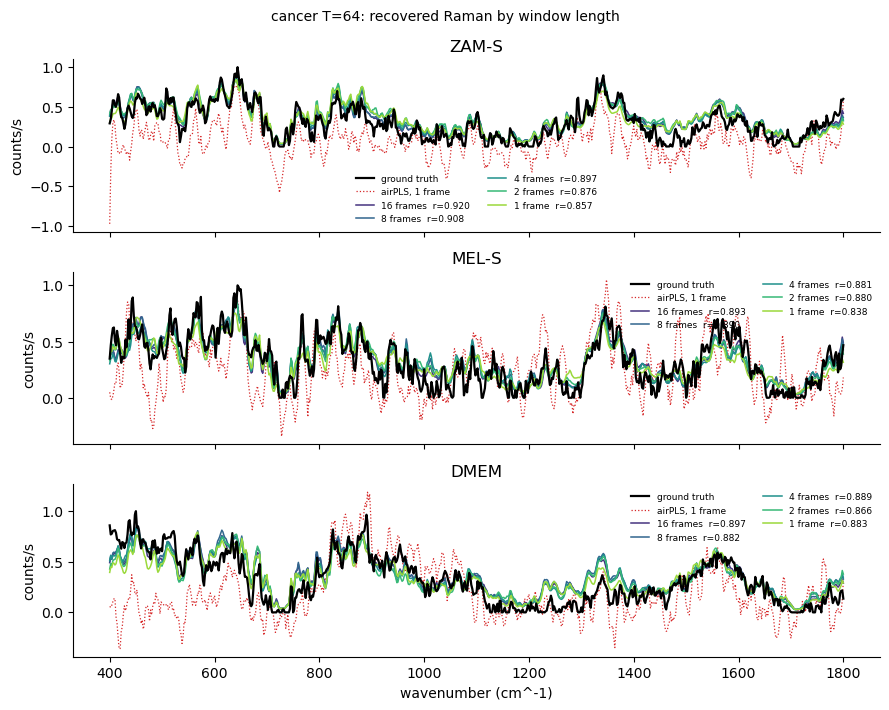

In [9]:
N_SHOW = 3
LABEL = next(iter(model_info))

info = model_info[LABEL]
m, d = info["model"], info["data"]
mask = eval_mask(d["wn"])
grid = [t for t in T_GRID if t <= m.hparams.n_times_train]
preds = {T: recover(m, d["ts"][:N_SHOW], T) for T in grid}
single = debaseline(d["ts"][:N_SHOW, 0, :] / d["frame_duration"])

colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(grid)))
fig, axes = plt.subplots(N_SHOW, 1, figsize=(9, 2.4 * N_SHOW), sharex=True)
for i, ax in enumerate(np.atleast_1d(axes)):
    ax.plot(d["wn"][mask], d["gt"][i][mask], "k", lw=1.6, label="ground truth", zorder=5)
    ax.plot(d["wn"][mask], single[i][mask], color="tab:red", lw=0.9, ls=":",
            label="airPLS, 1 frame")
    for colour, T in zip(colours, grid):
        r = pearson_r(d["gt"][i][mask], preds[T][i][mask])
        ax.plot(d["wn"][mask], preds[T][i][mask], color=colour, lw=1.1,
                label=f"{T} frame{'s' if T > 1 else ''}  r={r:.3f}")
    ax.set(ylabel="counts/s", title=d["labels"][i])
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=6.5, frameon=False, ncol=2)
axes[-1].set_xlabel("wavenumber (cm^-1)")
fig.suptitle(f"{LABEL}: recovered Raman by window length", fontsize=10)
plt.tight_layout()
plt.show()

### Peak sharpness

The instrument blur is a single Gaussian convolved with every peak, so nothing
in the output can be narrower than it. Fitted, it runs to its 15 cm-1 cap and
erases the band the Raman peaks live in; pinned to the value the optics imply
(4 cm-1 for this store, from the 3-4 cm-1 resolution of the source library) the
structure comes back.

Compare against `clean` rather than `gt`: the ground truth carries shot noise,
and a model should not be marked down for failing to reproduce it. The power
spectrum below is the same comparison without a peak-detection threshold, which
proved sensitive enough to reverse conclusions.


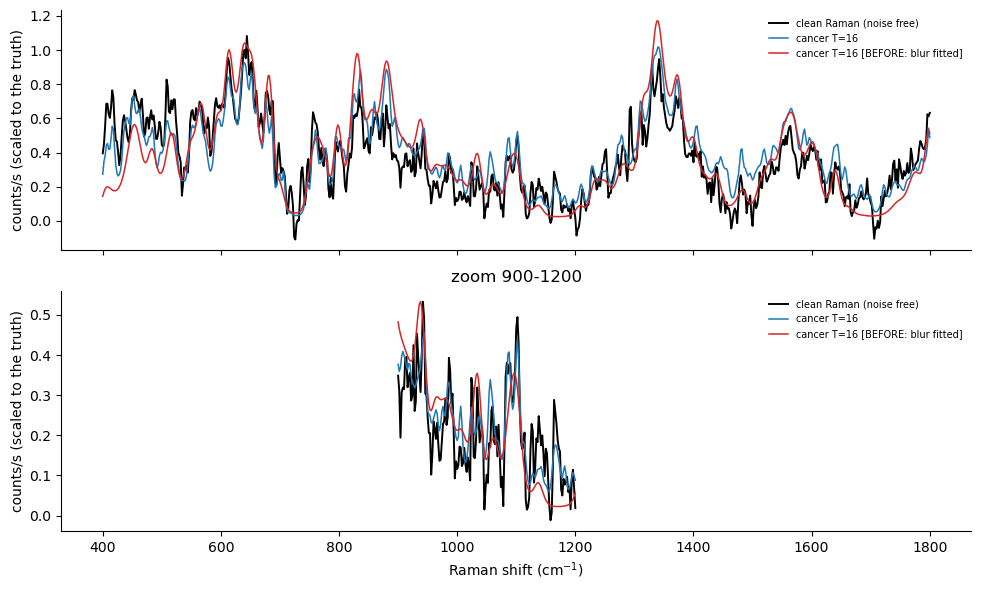

,60-,30-60,15-30,0-15
clean Raman (target),0.810,0.040,0.040,0.028
cancer T=16,0.875,0.056,0.046,0.010
cancer T=16 [BEFORE: blur fitted],0.930,0.035,0.014,0.000


In [10]:
ZOOM = (900, 1200)          # cm-1, a window where individual bands are visible
SAMPLE = 0
PAIR = ["cancer T=16", "cancer T=16 [BEFORE: blur fitted]"]

d = model_info[PAIR[0]]["data"]
sel = (d["wn"] >= ZOOM[0]) & (d["wn"] <= ZOOM[1])
ref = d["clean"] if d["clean"] is not None else d["gt"]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ax, (lo, hi) in zip(axes, [(d["wn"].min(), d["wn"].max()), ZOOM]):
    m_ = (d["wn"] >= lo) & (d["wn"] <= hi)
    ax.plot(d["wn"][m_], ref[SAMPLE][m_], "k", lw=1.4, label="clean Raman (noise free)")
    for label, colour in zip(PAIR, ["tab:blue", "tab:red"]):
        info = model_info[label]
        p = recover(info["model"], d["ts"][: SAMPLE + 1], 16)[SAMPLE]
        g = np.median(p[m_] @ ref[SAMPLE][m_] / (ref[SAMPLE][m_] @ ref[SAMPLE][m_]))
        ax.plot(d["wn"][m_], p[m_] / max(g, 1e-9), color=colour, lw=1.1, label=label)
    ax.set(ylabel="counts/s (scaled to the truth)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=7, frameon=False)
axes[1].set(xlabel="Raman shift (cm$^{-1}$)", title=f"zoom {ZOOM[0]}-{ZOOM[1]}")
plt.tight_layout()
plt.show()


def power_bands(a, step):
    """Share of spectral power by feature size. No threshold to choose."""
    a = a - a.mean(1, keepdims=True)
    f = np.abs(np.fft.rfft(a * np.hanning(a.shape[1]), axis=1)) ** 2
    f = f.mean(0) / f.mean(0).sum()
    freq = np.fft.rfftfreq(a.shape[1], d=step)
    per = np.where(freq > 0, 1 / np.maximum(freq, 1e-9), np.inf)
    return {f"{lo}-{hi if hi < 1e8 else ''}": f[(per >= lo) & (per < hi)].sum()
            for lo, hi in [(60, 1e9), (30, 60), (15, 30), (0, 15)]}


step = float(np.diff(d["wn"]).mean())
rows = {"clean Raman (target)": power_bands(ref, step)}
for label in PAIR:
    info = model_info[label]
    rows[label] = power_bands(recover(info["model"], d["ts"], 16), step)
pd.DataFrame(rows).T.round(3)


## The decomposition

The fluorescence is rebuilt from the model's own components rather than by
subtracting the Raman from the input, so the three curves are independent
predictions and their sum is a real check on the forward model.

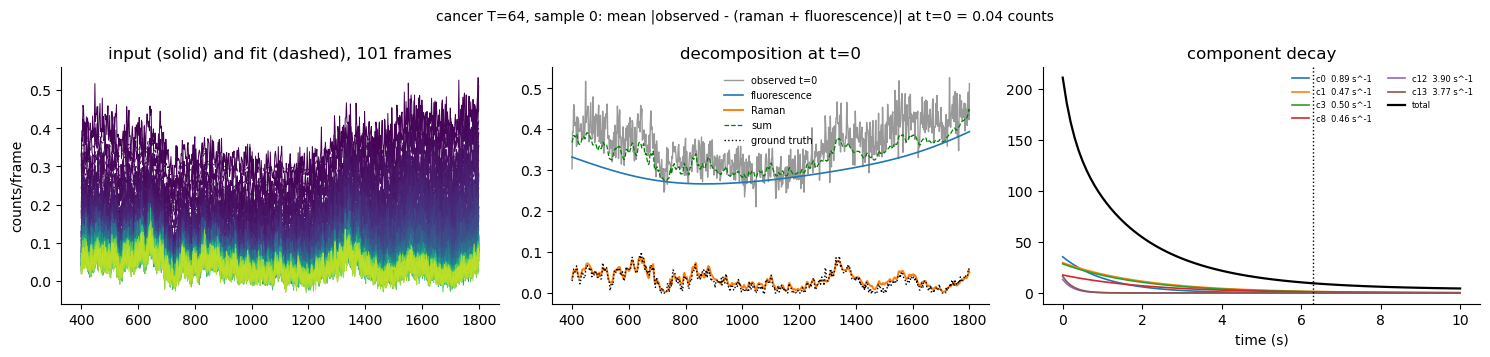

In [11]:
def show_decomposition(label, sample=0, n_show=6):
    info = model_info[label]
    m, d = info["model"], info["data"]
    wn, fd, mask = d["wn"], d["frame_duration"], eval_mask(d["wn"])
    n_times = m.hparams.n_times_train
    std = m.model.dataset_std
    device = next(m.parameters()).device

    x = torch.from_numpy(d["ts"][sample].astype(np.float32)).to(device).T / std  # [W, T]
    t_all = m.t_full.detach().cpu().numpy()
    n_t = min(x.shape[1], len(t_all))
    with torch.no_grad():
        _, _, _, lam, ab, raman, bases = m.model(x[None, :, :n_times], sample=False)
        recon, _ = m.model.physics_forward(lam, ab, raman, bases,
                                           time_values=m.t_full[:n_t].to(device))

    observed = (x.T.cpu().numpy() * std)[:n_t]          # [T, W], counts/frame
    recon = recon[0].T.cpu().numpy()
    raman_f = raman[0].cpu().numpy() * fd
    lam_np, ab_np, bases_np = (v[0].cpu().numpy() if v.ndim > 1 else v.cpu().numpy()
                               for v in (lam, ab, bases))
    bases_np = bases.cpu().numpy()

    # fluorescence(t) = sum_i a_i B_i(nu) exp(-lambda_i t)
    decay = np.exp(-lam_np[None, :] * t_all[:n_t, None])
    fluo = decay @ (ab_np[:, None] * bases_np)
    order = np.argsort(-ab_np)[:n_show]

    fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
    a = ax[0]
    for t, c in zip(range(n_t), plt.cm.viridis(np.linspace(0, 0.9, n_t))):
        a.plot(wn[mask], observed[t][mask], color=c, lw=0.7)
        a.plot(wn[mask], recon[t][mask], color=c, lw=0.7, ls="--")
    a.set(title=f"input (solid) and fit (dashed), {n_t} frames", ylabel="counts/frame")

    a = ax[1]
    a.plot(wn[mask], observed[0][mask], color="0.6", lw=1.0, label="observed t=0")
    a.plot(wn[mask], fluo[0][mask], lw=1.2, label="fluorescence")
    a.plot(wn[mask], raman_f[mask], lw=1.4, label="Raman")
    a.plot(wn[mask], (raman_f + fluo[0])[mask], "g--", lw=0.9, label="sum")
    a.plot(wn[mask], d["gt"][sample][mask] * fd, "k:", lw=1.0, label="ground truth")
    a.legend(fontsize=7, frameon=False)
    a.set(title="decomposition at t=0")

    a = ax[2]
    for i in order:
        a.plot(t_all[:n_t], decay[:, i] * (ab_np[i] * bases_np[i]).sum(), lw=1.2,
               label=f"c{i}  {lam_np[i]:.2f} s^-1")
    a.plot(t_all[:n_t], fluo.sum(1), "k", lw=1.6, label="total")
    a.axvline(t_all[n_times - 1], color="k", ls=":", lw=1)
    a.legend(fontsize=6, frameon=False, ncol=2)
    a.set(title="component decay", xlabel="time (s)")

    for a in ax:
        a.spines[["top", "right"]].set_visible(False)
    closure = np.abs(observed[0] - (raman_f + fluo[0])).mean()
    fig.suptitle(f"{label}, sample {sample}: mean |observed - (raman + fluorescence)| "
                 f"at t=0 = {closure:.2f} counts", fontsize=10)
    plt.tight_layout()
    plt.show()


show_decomposition(next(iter(model_info)), sample=0)

## Fluorophore identification

Synthetic stores only, since it needs per-sample ground-truth fluorophores.
Components are matched to true fluorophores by Hungarian assignment on cosine
similarity. Cosine between broad non-negative spectra saturates near 1, so the
rate and abundance correlations are the informative numbers.

In [12]:
for label, info in model_info.items():
    d = info["data"]
    if d["bases_gt"] is None:
        print(f"{label}: no ground-truth fluorophores in {d['name']}, skipping")
        continue

    m = info["model"]
    bases = m.model.bases.detach().cpu().numpy()
    bases_n = bases / (np.linalg.norm(bases, axis=1, keepdims=True) + 1e-9)
    std = m.model.dataset_std
    device = next(m.parameters()).device
    with torch.no_grad():
        x = torch.from_numpy(d["ts"][:, :m.hparams.n_times_train, :].astype(np.float32))
        _, _, _, rates, abund, _, _ = m.model(x.to(device).transpose(1, 2) / std,
                                              sample=False)
    rates, abund = rates.cpu().numpy(), abund.cpu().numpy()

    cos, tr, pr, ta, pa = [], [], [], [], []
    for n in range(len(d["idx"])):
        g = d["bases_gt"][n]
        g = g / (np.linalg.norm(g, axis=1, keepdims=True) + 1e-9)
        sim = g @ bases_n.T
        row, col = linear_sum_assignment(-sim)
        cos.append(sim[row, col])
        tr.append(d["rates_gt"][n][row]); pr.append(rates[n][col])
        ta.append(d["abund_gt"][n][row] / d["abund_gt"][n].sum())
        pa.append(abund[n][col] / (abund[n][col].sum() + 1e-12))
    cos, tr, pr, ta, pa = (np.concatenate(v) for v in (cos, tr, pr, ta, pa))

    print(f"{label}   ({bases.shape[0]} model components)")
    print(f"  matched cosine  {cos.mean():.4f}  (saturates, of limited use)")
    print(f"  log rate r      {np.corrcoef(np.log(tr), np.log(pr))[0, 1]:+.4f}")
    print(f"  abundance r     {np.corrcoef(ta, pa)[0, 1]:+.4f}")

cancer T=64   (16 model components)
  matched cosine  0.9853  (saturates, of limited use)
  log rate r      +0.1489
  abundance r     +0.1211
cancer T=16   (16 model components)
  matched cosine  0.9851  (saturates, of limited use)
  log rate r      +0.1710
  abundance r     +0.1745
cancer T=4   (16 model components)
  matched cosine  0.9908  (saturates, of limited use)
  log rate r      +0.1344
  abundance r     +0.1547
cancer T=1   (16 model components)
  matched cosine  0.9885  (saturates, of limited use)
  log rate r      +0.0611
  abundance r     +0.1161
cancer fixed T=16   (16 model components)
  matched cosine  0.9851  (saturates, of limited use)
  log rate r      +0.0116
  abundance r     +0.1620
cancer fixed T=4   (16 model components)
  matched cosine  0.9850  (saturates, of limited use)
  log rate r      +0.0045
  abundance r     +0.0034
cancer T=16 [BEFORE: blur fitted]   (16 model components)
  matched cosine  0.9816  (saturates, of limited use)
  log rate r      +0.0565
 